In [1]:
#  INCARCAREA SI EXPLORAREA DATA SETULUI BRMH

import pandas as pd
from pathlib import Path

# 1) Cautam fișierul în folderul curent și subfoldere (cloud/local)
patterns = [
    "**/EEG.machinelearning_data_BRMH*.csv",
    "**/EEG_machinelearning_data_BRMH*.csv",
    "**/*BRMH*.csv",
]

candidates = []
for pat in patterns:
    candidates += list(Path(".").glob(pat))

if not candidates:
    home = Path.home()
    for pat in patterns:
    
        candidates += list(home.glob(pat))

if not candidates:
    print("NU am găsit fișierul CSV în acest mediu.")
    print("Dacă folosești nb.anaconda.com (cloud), trebuie să UPLOADEZI fișierul în stânga (Upload).")
    print("După upload, rulează din nou celula.")
    raise FileNotFoundError("BRMH CSV not found")

data_path = str(candidates[0])
print("Am găsit fișierul aici:\n", data_path)

df = pd.read_csv(data_path)

print("\n" + "="*80)
print("DATASET BRMH - STATISTICI GENERALE")
print("="*80)
print(f"Dimensiuni: {df.shape[0]} rânduri × {df.shape[1]} coloane")
print("\nColoane disponibile:")
print(df.columns.tolist())

# Afișam primele rânduri (și verificăm dacă există coloanele mele )
cols = ['no.', 'sex', 'age', 'education', 'IQ', 'main.disorder', 'specific.disorder']
existing = [c for c in cols if c in df.columns]

print("\nPrimele 3 rânduri (coloane existente):", existing)
display(df[existing].head(3))


Am găsit fișierul aici:
 EEG.machinelearing_data_BRMH copy.csv

DATASET BRMH - STATISTICI GENERALE
Dimensiuni: 945 rânduri × 1149 coloane

Coloane disponibile:
['no.', 'sex', 'age', 'eeg.date', 'education', 'IQ', 'main.disorder', 'specific.disorder', 'AB.A.delta.a.FP1', 'AB.A.delta.b.FP2', 'AB.A.delta.c.F7', 'AB.A.delta.d.F3', 'AB.A.delta.e.Fz', 'AB.A.delta.f.F4', 'AB.A.delta.g.F8', 'AB.A.delta.h.T3', 'AB.A.delta.i.C3', 'AB.A.delta.j.Cz', 'AB.A.delta.k.C4', 'AB.A.delta.l.T4', 'AB.A.delta.m.T5', 'AB.A.delta.n.P3', 'AB.A.delta.o.Pz', 'AB.A.delta.p.P4', 'AB.A.delta.q.T6', 'AB.A.delta.r.O1', 'AB.A.delta.s.O2', 'AB.B.theta.a.FP1', 'AB.B.theta.b.FP2', 'AB.B.theta.c.F7', 'AB.B.theta.d.F3', 'AB.B.theta.e.Fz', 'AB.B.theta.f.F4', 'AB.B.theta.g.F8', 'AB.B.theta.h.T3', 'AB.B.theta.i.C3', 'AB.B.theta.j.Cz', 'AB.B.theta.k.C4', 'AB.B.theta.l.T4', 'AB.B.theta.m.T5', 'AB.B.theta.n.P3', 'AB.B.theta.o.Pz', 'AB.B.theta.p.P4', 'AB.B.theta.q.T6', 'AB.B.theta.r.O1', 'AB.B.theta.s.O2', 'AB.C.alpha.a.FP1', 'AB

,no.,sex,age,education,IQ,main.disorder,specific.disorder
0,1,M,57.0,NaN,NaN,Addictive disorder,Alcohol use disorder
1,2,M,37.0,6.0,120.0,Addictive disorder,Alcohol use disorder
2,3,M,32.0,16.0,113.0,Addictive disorder,Alcohol use disorder


In [2]:
import numpy as np
import pandas as pd

# 1) Problema corectă pentru research: Depresie vs Healthy control
df_bin = df[df["specific.disorder"].isin(["Depressive disorder", "Healthy control"])].copy()

# label: 1=Depresie, 0=Healthy
df_bin["label"] = (df_bin["specific.disorder"] == "Depressive disorder").astype(int)

print("Total samples:", len(df_bin))
print(df_bin["label"].value_counts())

# 2) Elimină coloane 'Unnamed' (apar din CSV)
unnamed_cols = [c for c in df_bin.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    print("Dropping Unnamed columns:", unnamed_cols[:5], "...")
    df_bin.drop(columns=unnamed_cols, inplace=True)

# 3) X / y: scoatem meta-coloanele (nu vrem model care trișează)
columns_to_drop = ["no.", "sex", "age", "education", "IQ", "main.disorder", "specific.disorder", "eeg.date", "label"]
X = df_bin.drop(columns=columns_to_drop, errors="ignore")
y = df_bin["label"].astype(int)

# păstrăm doar numeric, reparăm inf
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

print("X shape:", X.shape)
print("y shape:", y.shape)


Total samples: 294
label
1    199
0     95
Name: count, dtype: int64
Dropping Unnamed columns: ['Unnamed: 122'] ...
X shape: (294, 1140)
y shape: (294,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Test label counts:\n", y_test.value_counts())


Train: (235, 1140)  Test: (59, 1140)
Test label counts:
 label
1    40
0    19
Name: count, dtype: int64


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(0.0)),
    ("rf", RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        class_weight="balanced_subsample",
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST (Holdout 20%) ===")
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


=== RANDOM FOREST (Holdout 20%) ===
              precision    recall  f1-score   support

           0      0.375     0.158     0.222        19
           1      0.686     0.875     0.769        40

    accuracy                          0.644        59
   macro avg      0.531     0.516     0.496        59
weighted avg      0.586     0.644     0.593        59

Confusion matrix:
 [[ 3 16]
 [ 5 35]]
ROC-AUC: 0.6105263157894738


=== 5-fold CV ROC-AUC (mai stabil decât un singur split) ===
LogReg+SelectKBest: mean AUC=0.753  (std=0.081)
RandomForest: mean AUC=0.786  (std=0.064)
ExtraTrees: mean AUC=0.801  (std=0.073)

>>> BEST MODEL: ExtraTrees with CV AUC = 0.8013090418353578

=== HOLDOUT (Test 20%) ===
Confusion matrix:
 [[ 3 16]
 [ 3 37]]

Classification report:
               precision    recall  f1-score   support

           0      0.500     0.158     0.240        19
           1      0.698     0.925     0.796        40

    accuracy                          0.678        59
   macro avg      0.599     0.541     0.518        59
weighted avg      0.634     0.678     0.617        59

ROC-AUC: 0.6598684210526315


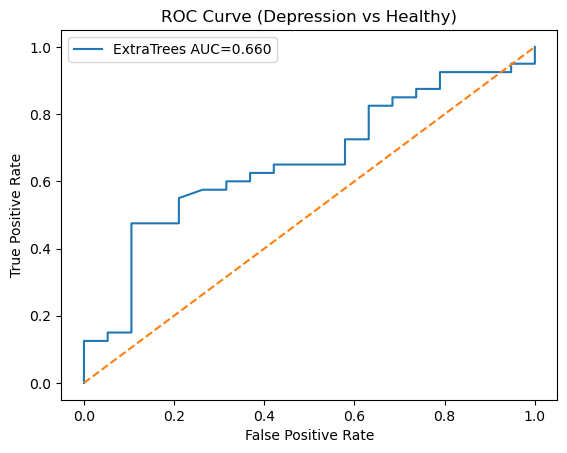

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "LogReg+SelectKBest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("var", VarianceThreshold(0.0)),
        ("select", SelectKBest(f_classif, k=200)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("var", VarianceThreshold(0.0)),
        ("clf", RandomForestClassifier(
            n_estimators=1200,
            random_state=42,
            class_weight="balanced_subsample",
            min_samples_leaf=1,
            min_samples_split=2,
            n_jobs=-1
        ))
    ]),
    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("var", VarianceThreshold(0.0)),
        ("clf", ExtraTreesClassifier(
            n_estimators=1500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=1,
            n_jobs=-1
        ))
    ])
}

print("=== 5-fold CV ROC-AUC (mai stabil decât un singur split) ===")
scores = {}
for name, pipe in models.items():
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    scores[name] = aucs.mean()
    print(f"{name}: mean AUC={aucs.mean():.3f}  (std={aucs.std():.3f})")

best_name = max(scores, key=scores.get)
best_model = models[best_name]
print("\n>>> BEST MODEL:", best_name, "with CV AUC =", scores[best_name])

# Fit pe train și evaluare pe test (holdout)
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("\n=== HOLDOUT (Test 20%) ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# ROC curve plot
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"{best_name} AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Depression vs Healthy)")
plt.legend()
plt.show()


In [6]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Alegem pragul care maximizează TPR - FPR (Youden index)
youden = tpr - fpr
best_threshold = thresholds[np.argmax(youden)]

print("Best threshold:", best_threshold)

y_pred_opt = (y_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_opt))
print("New ROC-AUC:", roc_auc_score(y_test, y_proba))


Best threshold: 0.7686666666666667
              precision    recall  f1-score   support

           0       0.45      0.89      0.60        19
           1       0.90      0.47      0.62        40

    accuracy                           0.61        59
   macro avg       0.68      0.68      0.61        59
weighted avg       0.76      0.61      0.61        59

New ROC-AUC: 0.6598684210526315


Top feature importances:
COH.A.delta.m.T5.n.P3: 0.007000
COH.B.theta.m.T5.n.P3: 0.005101
COH.A.delta.m.T5.o.Pz: 0.004156
COH.A.delta.a.FP1.e.Fz: 0.003895
COH.C.alpha.m.T5.n.P3: 0.003447
COH.C.alpha.e.Fz.n.P3: 0.003385
COH.A.delta.i.C3.m.T5: 0.003358
COH.B.theta.a.FP1.e.Fz: 0.003336
COH.B.theta.m.T5.o.Pz: 0.003168
COH.A.delta.m.T5.r.O1: 0.003146
COH.C.alpha.f.F4.n.P3: 0.003009
COH.C.alpha.a.FP1.n.P3: 0.002961
COH.A.delta.b.FP2.e.Fz: 0.002960
COH.A.delta.p.P4.q.T6: 0.002941
COH.A.delta.a.FP1.f.F4: 0.002935
COH.C.alpha.d.F3.n.P3: 0.002898
COH.A.delta.c.F7.h.T3: 0.002839
COH.A.delta.e.Fz.f.F4: 0.002838
COH.D.beta.a.FP1.e.Fz: 0.002714
COH.D.beta.m.T5.n.P3: 0.002628
COH.A.delta.j.Cz.m.T5: 0.002618
COH.B.theta.p.P4.q.T6: 0.002521
COH.A.delta.a.FP1.b.FP2: 0.002511
COH.B.theta.a.FP1.b.FP2: 0.002481
COH.A.delta.c.F7.d.F3: 0.002421


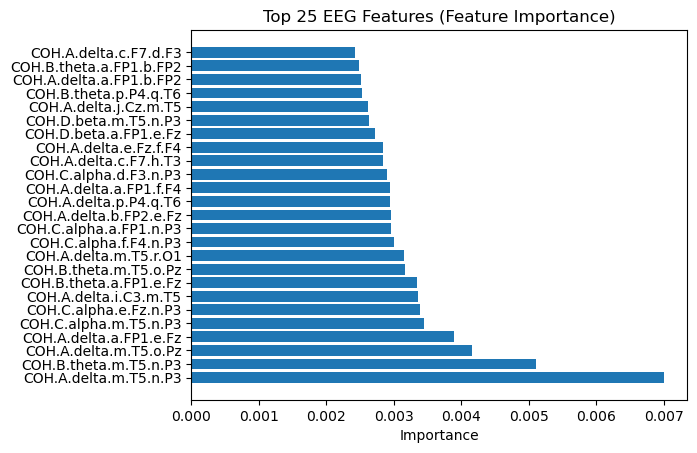

In [7]:
#FEATURE IMPORTANCE EEG
import numpy as np
import matplotlib.pyplot as plt

# IMPORTANT: acest cod presupune că ai deja:
# best_model (Pipeline cu imputer -> var -> clf) și X_train/X_test ca DataFrame cu nume de coloane

# 1) Extrage feature-names după VarianceThreshold
# (VarianceThreshold elimină coloane constante; trebuie să păstrăm doar cele rămase)
var_step = best_model.named_steps.get("var", None)
clf_step = best_model.named_steps.get("clf", None)

if var_step is None or clf_step is None:
    raise ValueError("Nu găsesc pașii 'var' sau 'clf' în best_model. Verifică pipeline-ul best_model.")

# get_support() marchează coloanele păstrate
mask = var_step.get_support()

# X_train e DataFrame -> are nume de coloane
feature_names_after_var = X_train.columns[mask]

# 2) Importanțe din model (ExtraTrees/RandomForest)
importances = clf_step.feature_importances_

# 3) Top N
N = 25
idx = np.argsort(importances)[::-1][:N]
top_features = feature_names_after_var[idx]
top_importances = importances[idx]

print("Top feature importances:")
for f, imp in zip(top_features, top_importances):
    print(f"{f}: {imp:.6f}")

# 4) Plot
plt.figure()
plt.barh(range(N)[::-1], top_importances[::-1])
plt.yticks(range(N)[::-1], top_features[::-1])
plt.xlabel("Importance")
plt.title(f"Top {N} EEG Features (Feature Importance)")
plt.show()


2026-02-12 23:58:52.517659: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 23:58:52.583569: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 23:58:57.808033: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


DL shapes: (235, 1140, 1) (59, 1140, 1)
Epoch 1/80


2026-02-12 23:58:59.527812: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.6862 - auc: 0.4502 - loss: 0.6702 - val_accuracy: 0.6383 - val_auc: 0.3431 - val_loss: 0.7044
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6862 - auc: 0.4247 - loss: 0.6477 - val_accuracy: 0.6383 - val_auc: 0.3882 - val_loss: 0.6669
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6862 - auc: 0.4262 - loss: 0.6462 - val_accuracy: 0.6383 - val_auc: 0.4000 - val_loss: 0.6660
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.6862 - auc: 0.4835 - loss: 0.6348 - val_accuracy: 0.6383 - val_auc: 0.4353 - val_loss: 0.6670
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6862 - auc: 0.5395 - loss: 0.6220 - val_accuracy: 0.6383 - val_auc: 0.4176 - val_loss: 0.6740
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.6809 - auc: 0.5259 - loss: 0.6219 - val_accuracy: 0.6383 - val_auc: 0.5088 - val_loss: 0.6679
Epoch 7/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step

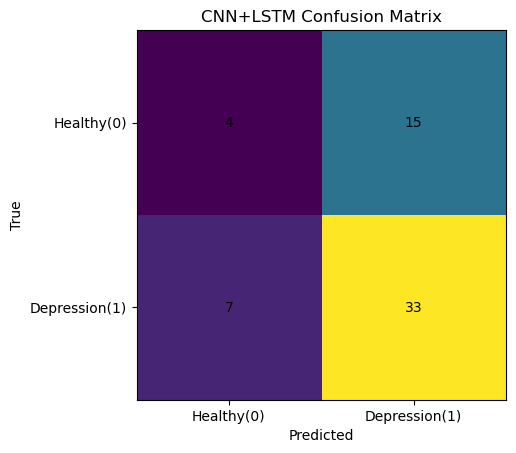

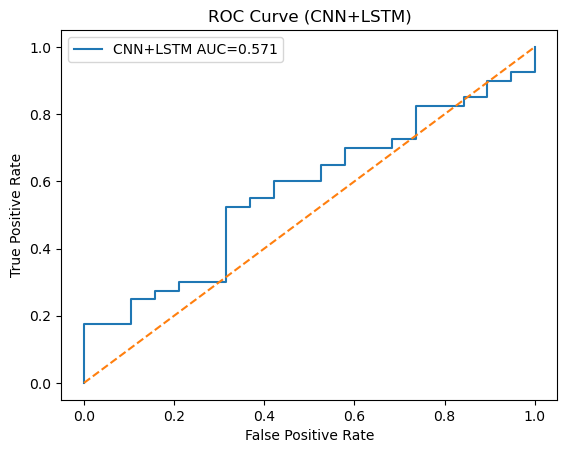

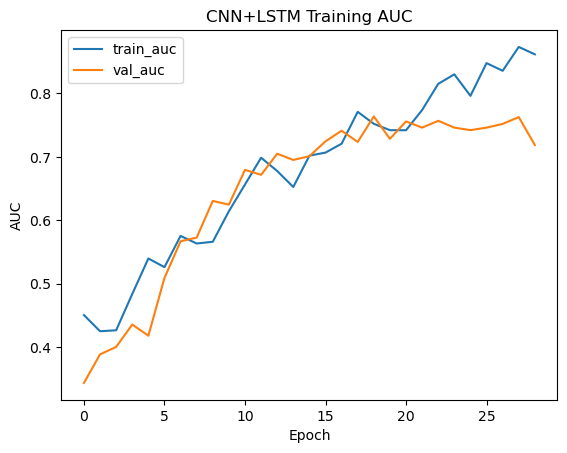

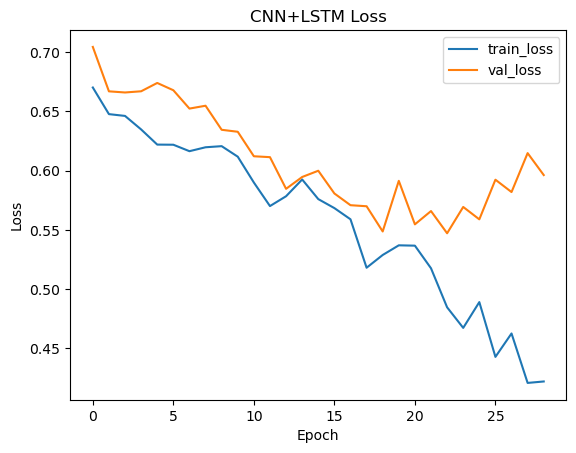

In [8]:
#CNN+LSTM
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

# 1) Impute + Scale (fit doar pe train)
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# 2) DL input: (samples, timesteps, channels)
X_train_dl = X_train_sc[..., np.newaxis]
X_test_dl  = X_test_sc[..., np.newaxis]

n_features = X_train_dl.shape[1]
print("DL shapes:", X_train_dl.shape, X_test_dl.shape)

# 3) Model CNN + LSTM (stabil pentru dataset mic)
tf.random.set_seed(42)

dl_model = models.Sequential([
    layers.Input(shape=(n_features, 1)),

    layers.Conv1D(32, kernel_size=7, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),

    layers.LSTM(64),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=10, restore_best_weights=True
    )
]

history = dl_model.fit(
    X_train_dl, y_train.values,
    validation_split=0.2,
    epochs=80,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

# 4) Evaluare
y_proba_dl = dl_model.predict(X_test_dl).ravel()
y_pred_dl = (y_proba_dl >= 0.5).astype(int)

auc_dl = roc_auc_score(y_test, y_proba_dl)
print("\n=== CNN+LSTM RESULTS (Holdout 20%) ===")
print("ROC-AUC:", auc_dl)
print(classification_report(y_test, y_pred_dl, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dl)
plt.figure()
plt.imshow(cm)
plt.title("CNN+LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["Healthy(0)", "Depression(1)"])
plt.yticks([0,1], ["Healthy(0)", "Depression(1)"])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_dl)
plt.figure()
plt.plot(fpr, tpr, label=f"CNN+LSTM AUC={auc_dl:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN+LSTM)")
plt.legend()
plt.show()

# Learning curves
plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("CNN+LSTM Training AUC")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN+LSTM Loss")
plt.legend()
plt.show()


In [9]:
#MODEL FINAL-PERFORMANTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    balanced_accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictii
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Performanțe calculate manual
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)   # Sensitivity
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
roc_auc = roc_auc_score(y_test, y_proba)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# PR curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

print("===== FINAL PERFORMANCE METRICS =====")
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")


===== FINAL PERFORMANCE METRICS =====
Accuracy: 0.678
Balanced Accuracy: 0.541
Precision: 0.698
Recall (Sensitivity): 0.925
Specificity: 0.158
F1-score: 0.796
ROC-AUC: 0.660
PR-AUC: 0.812


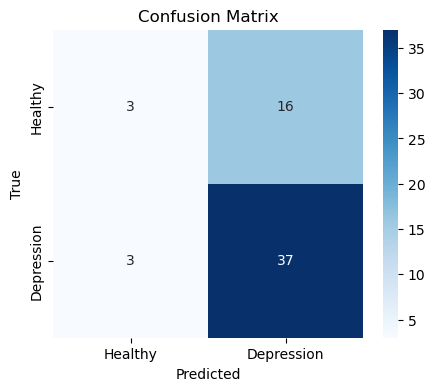

In [10]:
#Confusion Matrix Plot (profesional)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy", "Depression"],
            yticklabels=["Healthy", "Depression"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


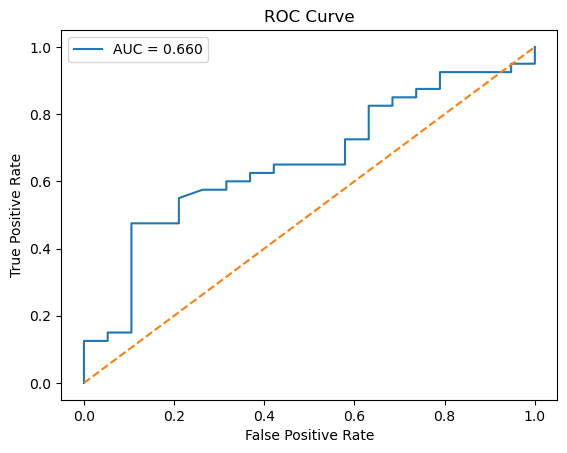

In [11]:
#ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


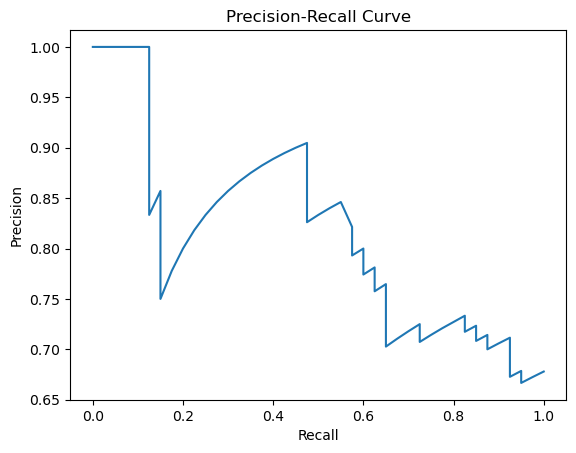

In [12]:
#Precision-Recall Curve (pentru proiecte medicale este foarte important)
plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [20]:
import numpy as np
import pandas as pd

def predict_from_existing_csv(model, original_df, X_reference, row_indices, threshold=0.5):
    """
    Predictie pentru rânduri din CSV-ul existent, folosind aceleași feature-uri ca la antrenare.
    
    model: best_model (Pipeline) deja antrenat
    original_df: df (datasetul complet)
    X_reference: X (DataFrame-ul cu feature-uri folosit la antrenare, înainte de split)
    row_indices: listă de indexuri (ex: [0,1,2])
    """

    # 1) Refacem X_all EXACT ca la train: scoatem coloanele non-feature
    columns_to_drop = [
        'no.', 'sex', 'age', 'education', 'IQ',
        'main.disorder', 'specific.disorder',
        'depression_label'
    ]
    X_all = original_df.drop(columns=columns_to_drop, errors='ignore')

    # 2) Elimină coloane "Unnamed"
    unnamed_cols = [c for c in X_all.columns if str(c).lower().startswith("unnamed")]
    if unnamed_cols:
        X_all = X_all.drop(columns=unnamed_cols, errors="ignore")

    # 3) Convertim la numeric (tot ce nu e numeric devine NaN)
    X_all = X_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

    # 4) IMPORTANT: aliniază exact coloanele ca la antrenare (X_reference)
    #    - păstrează doar coloanele folosite la train
    #    - dacă lipsesc, le adaugă cu NaN
    X_all = X_all.reindex(columns=X_reference.columns)

    # 5) Selectăm rândurile cerute
    X_new = X_all.iloc[row_indices]

    # 6) Predict
    proba = model.predict_proba(X_new)[:, 1]
    pred = (proba >= threshold).astype(int)

    results = pd.DataFrame({
        "Index": row_indices,
        "Probability_Depression": proba,
        "Predicted_Label": pred,
        "Predicted_Class": np.where(pred == 1, "Depression", "Healthy")
    })

    return results


In [22]:
results = predict_from_existing_csv(best_model, df, X, row_indices=[0,1,2,3,4], threshold=0.5)
results
#Prima variantă (threshold = 0.5)

,Index,Probability_Depression,Predicted_Label,Predicted_Class
0,0,0.840000,1,Depression
1,1,0.604667,1,Depression
2,2,0.704667,1,Depression
3,3,0.730000,1,Depression
4,4,0.857333,1,Depression


In [23]:
results = predict_from_existing_csv(
    best_model,
    df,
    X,
    row_indices=[0,1,2,3,4],
    threshold=best_threshold   # pragul optim găsit anterior
)


In [24]:
results.sort_values("Probability_Depression", ascending=False)
#A doua variantă (threshold = best_threshold)

,Index,Probability_Depression,Predicted_Label,Predicted_Class
4,4,0.857333,1,Depression
0,0,0.840000,1,Depression
3,3,0.730000,0,Healthy
2,2,0.704667,0,Healthy
1,1,0.604667,0,Healthy
